In [2]:
import numpy as np
import matplotlib.pyplot as plt
import adrienParamClassSheared as params
import adrienUtils as utils

In [3]:
# Load in simulation parameters from the parameter list
pList = params.generate()
p = pList["R1P1"]

x = np.linspace(0.0, p.Lx, p.Nx, endpoint=False)
y = np.linspace(0.0, p.Ly, p.Ny, endpoint=False)
z = np.linspace(0.0, p.Lz, p.Nz, endpoint=False)

In [4]:
# Load in actual simulation data  and check size
r = utils.load_binary("r",p)
b = -p.zAccel*r # buoyancy from density
del r
u = utils.load_binary("u",p)
v = utils.load_binary("v",p)
w = utils.load_binary("w",p)
u.shape

(1536, 768, 384)

In [5]:
# Check memory used by notebook
utils.memory_report(globals(), min_gb=0.2)

b                           1.69 GB  shape=(1536, 768, 384)  dtype=float32
u                           1.69 GB  shape=(1536, 768, 384)  dtype=float32
v                           1.69 GB  shape=(1536, 768, 384)  dtype=float32
w                           1.69 GB  shape=(1536, 768, 384)  dtype=float32

Notebook memory used     :   1.79 GB (  1.4 %)
Remaining available to me: 126.21 GB ( 98.6 %)
Container memory limit   : 128.00 GB
Total node memory        : 503.31 GB


In [12]:
eps = utils.compute_eps(p,u,v,w)
eps_avg = np.mean(eps)

<ε> = 2.820e-03
max ε / <ε> = 1.082e+02


In [9]:
# Check memory used by notebook
utils.memory_report(globals(), min_gb=0.2)

b                           1.69 GB  shape=(1536, 768, 384)  dtype=float32
u                           1.69 GB  shape=(1536, 768, 384)  dtype=float32
v                           1.69 GB  shape=(1536, 768, 384)  dtype=float32
w                           1.69 GB  shape=(1536, 768, 384)  dtype=float32
eps                         1.69 GB  shape=(1536, 768, 384)  dtype=float32
chi                         1.69 GB  shape=(1536, 768, 384)  dtype=float32

Notebook memory used     :  10.23 GB (  8.0 %)
Remaining available to me: 117.77 GB ( 92.0 %)
Container memory limit   : 128.00 GB
Total node memory        : 503.31 GB


In [8]:
chi = utils.compute_chi(p,b)
chi_avg = np.mean(chi)
np.max(chi[:, :, :]/chi_avg)

208.27563

In [23]:
print(f"<ε> = {eps_avg:.2e}")
print(f"<χ> = {chi_avg:.2e}")
print(f"max(ε/<ε>) = {np.max(eps[:, :, :]/eps_avg):.0f}")
print(f"max(χ/<χ>) = {np.max(chi[:, :, :]/chi_avg):.0f}")

<ε> = 2.82e-03
<χ> = 5.41e-04
max(ε/<ε>) = 108
max(χ/<χ>) = 208


In [24]:
# Compute average quantities 
Gamma = chi_avg/eps_avg 
N2 = -p.dGrad*p.zAccel
Ri = N2
Reb = eps_avg/(p.kinV*N2)
Ek = np.mean((u.flatten())**2+(v.flatten())**2+(w.flatten())**2)/2
Ek_pct = 100 * Ek / p.targKE
Ep = np.mean((b.flatten())**2)/(2*N2)
RPK = Ep/Ek

print(f"Ri = {Ri:.3f}")
print(f"Γ = {Gamma:.3f}")
print(f"Reb = {Reb:.1f}")
print(f"Measured Ek = {Ek:.3e} ({Ek_pct:.2f}% of target)")
print(f"Measured Ep = {Ep:.3e}")
print(f"RPK = {RPK:.2f}")

<χ> = 5.407e-04
Ri = 0.164
Γ = 0.192
Reb = 34.5
Measured Ek = 1.579e-02 (99.97% of target)
Measured Ep = 2.406e-03
RPK = 0.15


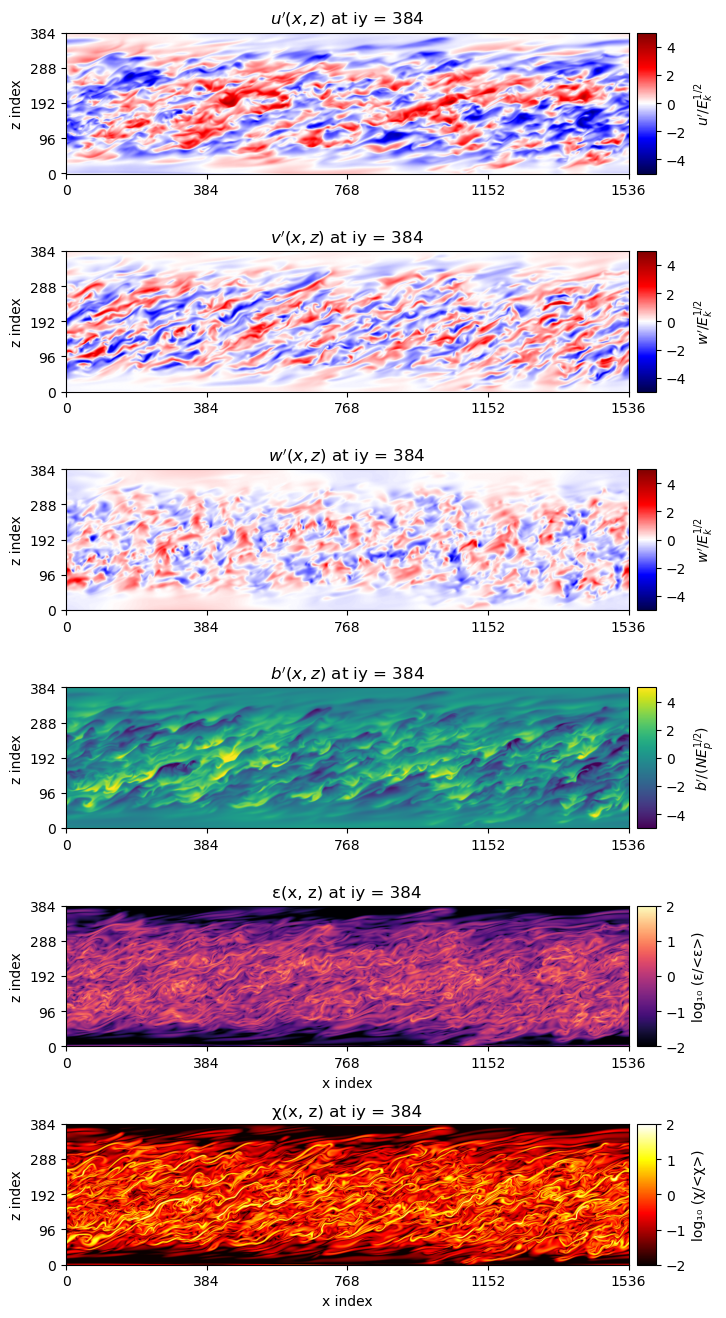

In [25]:
# Plot slices of the perturbations

# Pick a y index and plot vertical slices (here in the middle)
yIdx = p.Ny // 2

fig, axs = plt.subplots(6, 1, figsize=(10, 16))
fig.subplots_adjust(hspace=0.55)

utils.imshow_with_cbar(axs[0], u[:, yIdx, :]/np.sqrt(Ek), "seismic", -5, 5, "$u'/E_k^{1/2}$")
axs[0].set_title(f"$u'(x, z)$ at iy = {yIdx}")
utils.set_index_axis(axs[0], "x", p.Nx, " ")
utils.set_index_axis(axs[0], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[1], v[:, yIdx, :]/np.sqrt(Ek), "seismic", -5, 5, "$w'/E_k^{1/2}$")
axs[1].set_title(f"$v'(x, z)$ at iy = {yIdx}")
utils.set_index_axis(axs[1], "x", p.Nx, " ")
utils.set_index_axis(axs[1], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[2], w[:, yIdx, :]/np.sqrt(Ek), "seismic", -5, 5, "$w'/E_k^{1/2}$")
axs[2].set_title(f"$w'(x, z)$ at iy = {yIdx}")
utils.set_index_axis(axs[2], "x", p.Nx, " ")
utils.set_index_axis(axs[2], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[3], b[:, yIdx, :]/np.sqrt(N2*Ep), "viridis", -5, 5, "$b'/(NE_p^{1/2})$")
axs[3].set_title(f"$b'(x, z)$ at iy = {yIdx}")
utils.set_index_axis(axs[3], "x", p.Nx, " ")
utils.set_index_axis(axs[3], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[4], np.log10(eps[:, yIdx, :]/eps_avg), "magma", -2, 2, "log₁₀ (ε/<ε>)")
axs[4].set_title(f"ε(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[4], "x", p.Nx, "x index")
utils.set_index_axis(axs[4], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[5], np.log10(chi[:, yIdx, :]/chi_avg), "hot", -2, 2, "log₁₀ (χ/<χ>)")
axs[5].set_title(f"χ(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[5], "x", p.Nx, "x index")
utils.set_index_axis(axs[5], "y", p.Nz, "z index")

In [78]:
utils.save_slice_figure(
    fig,
    p,
    slice_dir="y",
    idx=yIdx,
    outdir="figures",
    fmt="png",
    dpi=500
)

Saved -> figures/R1P1_slice_y384_20260130_062925.png


PosixPath('figures/R1P1_slice_y384_20260130_062925.png')

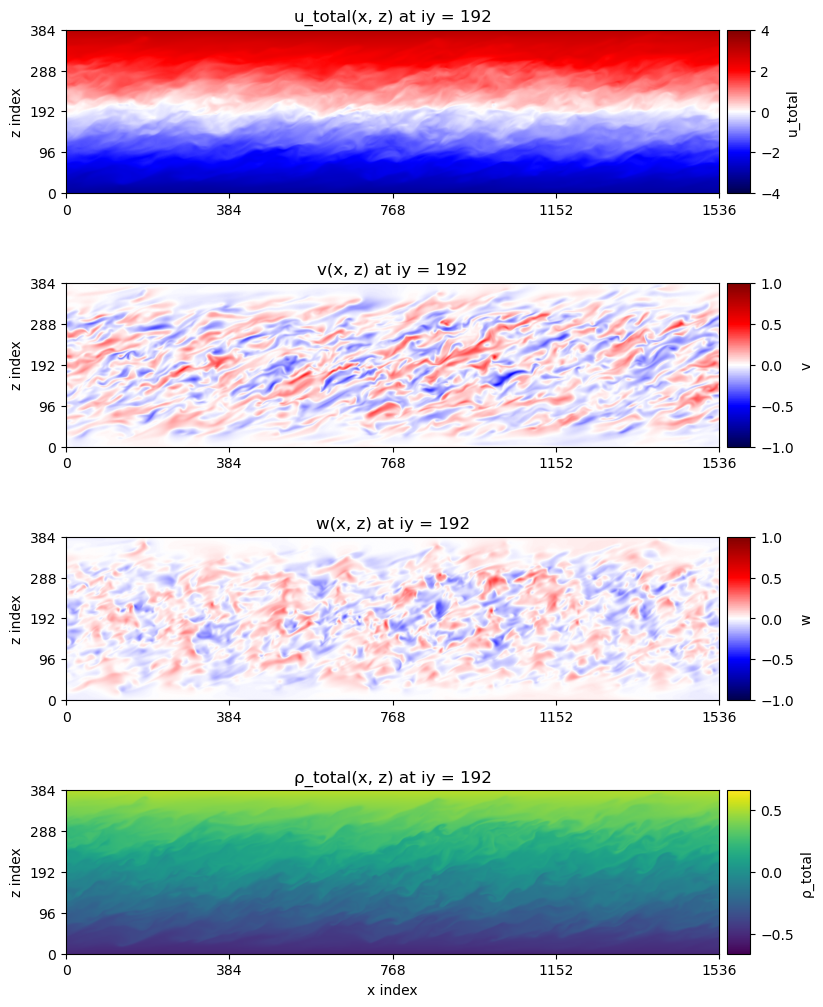

In [27]:
# Plot several slices of the TOTAL fields

# Define background fields U(z) = z and B(z) = N^2 * z = Ri * z
dz = p.Lz/p.Nz
z_centre = (np.arange(p.Nz) - p.Nz/2)*dz # so that z=0 in the middle
Uz = z_centre;
Bz = -p.dGrad * p.zAccel * z_centre # equivalently, N2*z_centre

# Pick a y index and plot vertical slices (here in the middle)
yIdx = p.Ny // 4

fig, axs = plt.subplots(4, 1, figsize=(10, 12))
fig.subplots_adjust(hspace=0.55)

utils.imshow_with_cbar(axs[0], u[:, yIdx, :] + Uz, "seismic", -4, 4, "u_total");  
axs[0].set_title(f"u_total(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[0], "x", p.Nx, " ")
utils.set_index_axis(axs[0], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[1], v[:, yIdx, :], "seismic", -1, 1, "v"); 
axs[1].set_title(f"v(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[1], "x", p.Nx, " ")
utils.set_index_axis(axs[1], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[2], w[:, yIdx, :], "seismic", -1, 1, "w");  
axs[2].set_title(f"w(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[2], "x", p.Nx, " ")
utils.set_index_axis(axs[2], "y", p.Nz, "z index")

utils.imshow_with_cbar(axs[3], b[:, yIdx, :] + Bz, "viridis", -4*Ri, 4*Ri, "ρ_total");  
axs[3].set_title(f"ρ_total(x, z) at iy = {yIdx}")
utils.set_index_axis(axs[3], "x", p.Nx, " ")
utils.set_index_axis(axs[3], "y", p.Nz, "z index")
utils.set_index_axis(axs[3], "x", p.Nx, "x index")

In [86]:
utils.save_slice_figure(
    fig,
    p,
    slice_dir="y",
    idx=yIdx,
    outdir="figures",
    fmt="jpg",
    dpi=300
)

Saved -> figures/R1P1_slice_y192_20260130_063413.jpg


PosixPath('figures/R1P1_slice_y192_20260130_063413.jpg')

In [29]:
print("u_total min:", np.min(u[:, yIdx, :] + Uz))
print("u_total max:", np.max(u[:, yIdx, :] + Uz))
print("b_total min:", np.min(b[:, yIdx, :] + Bz))
print("b_total max:", np.max(b[:, yIdx, :] + Bz))

u_total min: -3.179709570603915
u_total max: 3.181760600413576
b_total min: -0.5196866126595091
b_total max: 0.5184998350456198
